In [ ]:
# Direct wrappers
#
# https://tslearn.readthedocs.io/en/latest/gen_modules/tslearn.clustering.html#module-tslearn.clustering
# https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.clustering.k_medoids.TimeSeriesKMedoids.html#sktime.clustering.k_medoids.TimeSeriesKMedoids


%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import random

# feature: addition of interpolation, smoothing and resolution selection
# feature: possibility to combine different clustering methods
# 
from timex.clustering import model_based_clustering # model-based clustering
from timex.clustering import distance_based_clustering # distance-based clustering
from timex.clustering import feature_based_clustering # feature-based clustering
from timex.clustering import meta_clustering # meta algorithms, to combine the different methods


from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score


In [34]:
AKI_PATH = os.environ['AKI_PATH_NEW']
os.chdir(AKI_PATH)

ts_data = pd.read_parquet("data_preparation_DV_final_for_LCMM_19785AKIpatients_FU7-3650d_SW365d_TR90d_13032025.parquet")
ts_data = ts_data.assign(ID=ts_data.ID.astype('int64'))

TEST = True

In [35]:
# X = [n_ts, sz, dim]
# if there is no interpolation we assume that the time dimension is the second one
# i.e. we have at least 2 dimensions

ts_data = ts_data.rename(columns={"Time_since_index_AKI_days": "Time_days"})

In [36]:
ts_data = ts_data[['Time_days', 'eGFR_int', 'ID']]

In [37]:
if TEST:
    test_selection = random.choices(ts_data.ID.unique().tolist(), k=250)
else:
    test_selection = ts_data.ID.unique().tolist()

In [38]:
clusters_8_timexCustom_outwards = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                              'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3,
                                    how='normal', 
                                    num_samples=2000,
                                    direction='outwards',
                                    normalize=True)


Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:08<00:00, 288.12it/s, 15 steps of size 2.13e-01. acc. prob=0.86] 


cl pos: 31
cl neg: 31
# series: 249, remaining: 187, RMSE_p: 0.17884941399097443, RMSE_n: 0.1295362114906311
Running LMM splitter..


<string>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
sample: 100%|██████████| 2500/2500 [00:07<00:00, 332.91it/s, 31 steps of size 1.71e-01. acc. prob=0.83]


cl pos: 31
cl neg: 31
# series: 187, remaining: 125, RMSE_p: 0.43115857243537903, RMSE_n: 0.4794330894947052
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:06<00:00, 382.02it/s, 15 steps of size 1.40e-01. acc. prob=0.91]


cl pos: 31
Removing overlap: 8
cl neg: 23
# series: 125, remaining: 71, RMSE_p: 0.5297276377677917, RMSE_n: 0.6008623838424683
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:05<00:00, 428.79it/s, 31 steps of size 9.25e-02. acc. prob=0.94]


cl pos: 31
Removing overlap: 4
cl neg: 27
# series: 71, remaining: 13, RMSE_p: 0.4443393051624298, RMSE_n: 0.4367341697216034
Assigned 8 clusters, assigning remaning 13 series to remainder clusters


In [39]:
[len(c) for c in clusters_8_timexCustom_outwards], sum([len(c) for c in clusters_8_timexCustom_outwards]), len(test_selection)

([31, 31, 31, 31, 31, 23, 31, 27, 13], 249, 250)

In [40]:
clusters_8_timexCustom_inwards = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                              'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3,
                                    how='normal', 
                                    num_samples=2000,
                                    direction='inwards',
                                    normalize=True)


Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:10<00:00, 234.57it/s, 15 steps of size 2.13e-01. acc. prob=0.86] 
<string>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


cl pos: 31
cl neg: 31
# series: 249, remaining: 187, RMSE_p: 0.7812473177909851, RMSE_n: 0.9018138647079468
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:06<00:00, 393.77it/s, 15 steps of size 1.94e-01. acc. prob=0.74]


cl pos: 31
Removing overlap: 4
cl neg: 27
# series: 187, remaining: 129, RMSE_p: 0.6969919800758362, RMSE_n: 0.9004367589950562
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:04<00:00, 540.01it/s, 15 steps of size 3.15e-01. acc. prob=0.86]


cl pos: 31
Removing overlap: 21
cl neg: 10
# series: 129, remaining: 88, RMSE_p: 0.6788051128387451, RMSE_n: 0.8258358836174011
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:05<00:00, 437.38it/s, 15 steps of size 3.14e-01. acc. prob=0.89]


cl pos: 31
Removing overlap: 14
cl neg: 17
# series: 88, remaining: 40, RMSE_p: 0.5546706318855286, RMSE_n: 0.6776841282844543
Assigned 8 clusters, assigning remaning 40 series to remainder clusters


In [41]:
[len(c) for c in clusters_8_timexCustom_inwards], sum([len(c) for c in clusters_8_timexCustom_inwards]), len(test_selection)

([31, 31, 31, 27, 31, 10, 31, 17, 40], 249, 250)

In [42]:
clusters_8_mm_slope = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                                            'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    how='slope',
                                    num_samples=1500,
                                    normalize=True)

sample: 100%|██████████| 2000/2000 [00:11<00:00, 171.98it/s, 31 steps of size 1.28e-01. acc. prob=0.89]

(249, 6)


In [43]:
[len(c) for c in clusters_8_mm_slope], sum([len(c) for c in clusters_8_mm_slope]), len(test_selection)

([46, 79, 30, 33, 4, 23, 28, 6], 249, 250)

In [44]:
clusters_8_mm_rec = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                                            'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    how='random_effect_clustering',
                                    num_samples=2000,
                                    num_warmup=500,
                                    normalize=True)

sample: 100%|██████████| 2500/2500 [00:14<00:00, 170.64it/s, 31 steps of size 1.27e-01. acc. prob=0.89]


In [45]:
[len(c) for c in clusters_8_mm_rec], sum([len(c) for c in clusters_8_mm_rec]), len(test_selection)

([20, 5, 22, 14, 19, 17, 55, 97], 249, 250)

In [46]:
clusters_8_mm_ric = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                                            'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    how='random_intercept_clustering',
                                    num_samples=1500,
                                    num_warmup=500,
                                    normalize=True)

sample: 100%|██████████| 2000/2000 [00:05<00:00, 380.03it/s, 15 steps of size 2.89e-01. acc. prob=0.89]


In [47]:
clusters_8_lmm = model_based_clustering.clustering_lmm(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=8, 
                                    spline_degree=4, 
                                    num_samples=2000,
                                    num_warmup=500,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    num_chains=1,
                                    vi = False,
                                    tau = 10,
                                    normalize=True, 
                                    adaptive_spline=True)

Characteristics of B_obs
min max cond#
0.0 1.0 85.09611
Defining kernel...
Init sampler...
Start sampler...


sample: 100%|██████████| 2500/2500 [01:22<00:00, 30.27it/s, 63 steps of size 6.31e-02. acc. prob=0.91] 


Start posterior draws...


In [48]:
[len(c) for c in clusters_8_lmm]

[8, 67, 22, 37, 23, 45, 30, 17]

In [49]:
clusters_8_lmm_vi = model_based_clustering.clustering_lmm(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=5, 
                                    spline_degree=4, 
                                    num_steps=1000,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    vi = True,
                                    tau_search = False,
                                    tau = 5,
                                    normalize=True, 
                                    adaptive_spline=True)

100%|██████████| 1000/1000 [00:03<00:00, 332.32it/s, init loss: 56047.6719, avg. loss [951-1000]: 7383.5449]


(500, 249, 8)


In [50]:
[len(c) for c in clusters_8_lmm_vi]

[0, 7, 217, 0, 0, 19, 0, 6]

In [51]:
sum([len(c) for c in clusters_8_mm_slope])

249

In [52]:
LOL = { 'lmm_vi': [i for i,c in enumerate(clusters_8_lmm_vi) for _c in c],
        'lmm':[i for i,c in enumerate(clusters_8_lmm) for _c in c],
        'mm_ric':[i for i,c in enumerate(clusters_8_mm_ric) for _c in c],
        'mm_rec':[i for i,c in enumerate(clusters_8_mm_rec) for _c in c], 
        'mm_slope':[i for i,c in enumerate(clusters_8_mm_slope) for _c in c],    
        'mm_inw':[i for i,c in enumerate(clusters_8_timexCustom_inwards) for _c in c], 
        'mm_out':[i for i,c in enumerate(clusters_8_timexCustom_outwards) for _c in c]
}

# get stats
res = []
for k,v1 in LOL.items():
    for l,v2 in LOL.items():
        res.append({
            'm1': k,
            'm2': l, 
            'ami': adjusted_mutual_info_score(v1,v2), 
            'ari': adjusted_rand_score(v1,v2)
            }) 
        


In [ ]:
ami_cm = pd.DataFrame(res).pivot(index='m1', columns='m2', values='ami')
ari_cm = pd.DataFrame(res).pivot(index='m1', columns='m2', values='ari')

In [ ]:
# add heatmap
sns.heatmap(ari_cm, annot=True)

In [ ]:
# add heatmap
sns.heatmap(ami_cm, annot=True)

ValueError: could not convert string to float: 'lmm_vi'

: 

In [29]:
res_list = []
for clnum, idlist in enumerate(clusters_8_timexCustom_outwards):
    for id in idlist:
        res_list.append({
            'clusters_8_mm_slope': clnum, 
            'ID': id
        })

ts_data = pd.merge(ts_data, pd.DataFrame(res_list), how='left', on='ID')


In [30]:
ts_data = ts_data.fillna(-1)

<Axes: xlabel='Time_days', ylabel='eGFR_int'>

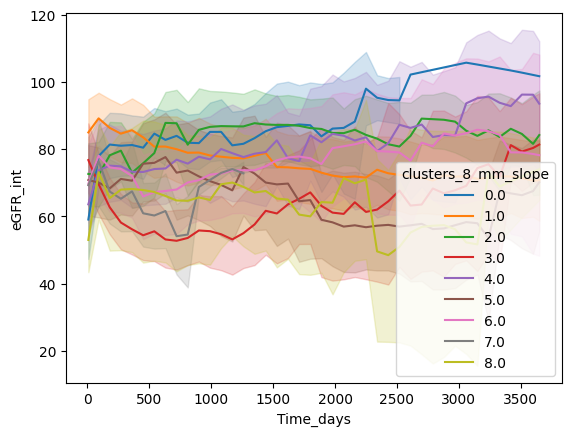

In [31]:
sns.lineplot(ts_data[ts_data.ID.isin(test_selection)], x='Time_days', y='eGFR_int', 
             hue='clusters_8_mm_slope', palette='tab10')

In [ ]:
num_plots_per_clusters = 100

cmap_ = plt.get_cmap('tab10', len(clusters_8))
cluster_colors = {c: cmap_(c) for c in range(len(clusters_8))}

fig, ax = plt.subplots(figsize=(18, 8))

for ck, cl in enumerate(clusters_8):
    for sid in random.choices(cl, k=num_plots_per_clusters):
        sub = ts_data[ts_data['ID'] == sid]
        ax.plot(sub['Time_days'], sub['eGFR_int'], lw=2, label=ck, color=cluster_colors[ck], alpha=0.1)
ax.set_title('Timeseries by Predicted Cluster')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='small')